# Sales Analysis 

# Table of Contents
<ul>
<li><a href="#intro">Background Information</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

### Background information

In this Notebook i will use Python Pandas & Python Matplotlib to analyze and answer business questions about 12 months worth of sales data. The data contains hundreds of thousands of electronics store purchases broken down by order Number and it's date, product type and it's quantity, cost and purchase address

# Dataset Varibale:-
Each dataset has:

Order Id: The id of the order.

Product: The type of the product bought.

Quantity Ordered: How many of the product was ordered.

Price Each: The price of a single item.

Order Date: When the product was ordered including the year,month, day, hours and minutes

Purchase Adrress: Where to deliver the order.

# Questions: 
Question 1: What was the best month for sales? How much was earned that month?

Question 2 : Which city had the highest number of sales?

Question 3: What time should we display advertisements to maximize the likelihood of purchasses and Sales?

Question 4: What products are most often sold together?

Question 5: Which product was sold the most?

In [1]:
import pandas as pd #to read, clean, explore and answer questions about our data
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt #to visualize our data
plt.style.use('fivethirtyeight') #The style of our plots

import os #to get our 12 csv files from the working directory into a single list

# Data wrangling
load in the data, check for cleanliness, and then trim and clean your dataset for analysis.

###  Let's aggregate our data

In [2]:
files = [i for i in os.listdir('./Sales_Data')] #collect the files in a single list

y_2019 = pd.DataFrame() # An empty datat frame to gather the files in

for i in files: # Concating the files in a single data frame
    y_2019 = pd.concat([y_2019, pd.read_csv('./Sales_Data/'+i)])

#storing the uncleaned data in a csv file
y_2019.to_csv('all_data.csv' , index = False)    

In [3]:
df = pd.read_csv('all_data.csv')
df.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"
186849,259357,USB-C Charging Cable,1,11.95,09/30/19 00:18,"250 Meadow St, San Francisco, CA 94016"


In [4]:
df.shape

(186850, 6)

In [5]:
#some summary statistics
df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,355,21903,168552,21903,355,355


We can conclude the following:

1-All the cells are in string format

2- USB-C Charging Cable is the most sold product with 21903 order

3- the prsence of strings in the 3rd row with the same name of the coulmns [Order Date , Purchase Address] with high freq is a sign for dublicates and must be removed

In [6]:
# more information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


##### Since we have more entries than the non-null values in each column this tells us that there're cells with NaN values

## Cleaning the data

###### We need to change the type of some coulmns to integer type rather than stirngs type, but first NaN and dublicates of string in each column must be removed

In [7]:
df.isna().sum() ##check how many NaN values are in each column

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [8]:
df[df.isna().any(axis = 1)] ##showing the rows with NaN values

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1,NaN,NaN,NaN,NaN,NaN,NaN
356,NaN,NaN,NaN,NaN,NaN,NaN
735,NaN,NaN,NaN,NaN,NaN,NaN
1433,NaN,NaN,NaN,NaN,NaN,NaN
1553,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
185176,NaN,NaN,NaN,NaN,NaN,NaN
185438,NaN,NaN,NaN,NaN,NaN,NaN
186042,NaN,NaN,NaN,NaN,NaN,NaN
186548,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.dropna(how='all',inplace = True) # droping rows with NaN values

In [10]:
df.isna().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

Perfect no more NaN rows in our data

In [11]:
print('there are {} order'.format(df.shape[0]))

there are 186305 order


# -----------------------------------------------------------
##### Now let's check duplicates

In [12]:
df.duplicated().sum() #check how many rows are identical to each other in the data

618

In [13]:
df.loc[df.duplicated() , :] #showing the dublicates

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
31,176585,Bose SoundSport Headphones,1,99.99,04/07/19 11:31,"823 Highland St, Boston, MA 02215"
1149,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1155,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1302,177795,Apple Airpods Headphones,1,150,04/27/19 19:45,"740 14th St, Seattle, WA 98101"
1684,178158,USB-C Charging Cable,1,11.95,04/28/19 21:13,"197 Center St, San Francisco, CA 94016"
...,...,...,...,...,...,...
186563,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186632,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186738,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186782,259296,Apple Airpods Headphones,1,150,09/28/19 16:48,"894 6th St, Dallas, TX 75001"


#### Looks like some rows have values of columns names

In [14]:
df.loc[(df.Product == 'Product') & (df.duplicated(keep = False , subset= df.columns)) , :] #showing those rows

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
519,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1149,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1155,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2878,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2893,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
185164,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
185551,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186563,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186632,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


##### There are 355 rows which values is the same as the columns names

In [15]:
df.drop(df[df.Product == 'Product'].index , inplace = True) #Removing those rows  

In [16]:
df.loc[df.duplicated(keep = False) , :]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
30,176585,Bose SoundSport Headphones,1,99.99,04/07/19 11:31,"823 Highland St, Boston, MA 02215"
31,176585,Bose SoundSport Headphones,1,99.99,04/07/19 11:31,"823 Highland St, Boston, MA 02215"
1301,177795,Apple Airpods Headphones,1,150,04/27/19 19:45,"740 14th St, Seattle, WA 98101"
1302,177795,Apple Airpods Headphones,1,150,04/27/19 19:45,"740 14th St, Seattle, WA 98101"
1682,178158,USB-C Charging Cable,1,11.95,04/28/19 21:13,"197 Center St, San Francisco, CA 94016"
...,...,...,...,...,...,...
186508,259035,27in FHD Monitor,1,149.99,09/29/19 13:52,"327 Lake St, San Francisco, CA 94016"
186781,259296,Apple Airpods Headphones,1,150,09/28/19 16:48,"894 6th St, Dallas, TX 75001"
186782,259296,Apple Airpods Headphones,1,150,09/28/19 16:48,"894 6th St, Dallas, TX 75001"
186784,259297,Lightning Charging Cable,1,14.95,09/15/19 18:54,"138 Main St, Boston, MA 02215"


Now 528 rows are identical, this means that the same customer bought the same product more than once at the same time 

###### No need to remove more rows

Fixing the datatype of the columns

In [17]:
df['Quantity Ordered'] = df['Quantity Ordered'].astype('int32')
df['Price Each'] = df['Price Each'].astype(float)

In [18]:
#Summary statistics for quauntative columns
df.describe()

,Quantity Ordered,Price Each
count,185950.000000,185950.000000
mean,1.124383,184.399735
std,0.442793,332.731330
min,1.000000,2.990000
25%,1.000000,11.950000
50%,1.000000,14.950000
75%,1.000000,150.000000
max,9.000000,1700.000000


### fixing order date column and sorting the dataframe

In [19]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values(by=['Order Date'])

In [20]:
df['N_Month'] = df['Order Date'].dt.month # adding a column for months number
df['Sales'] = df['Quantity Ordered'] * df['Price Each'] #adding columns for the sale of the order
df['Year'] = df['Order Date'].dt.year # adding a column for the year
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,N_Month,Sales,Year
73891,147268,Wired Headphones,1,11.99,2019-01-01 03:07:00,"9 Lake St, New York City, NY 10001",1,11.99,2019
74701,148041,USB-C Charging Cable,1,11.95,2019-01-01 03:40:00,"760 Church St, San Francisco, CA 94016",1,11.95,2019
76054,149343,Apple Airpods Headphones,1,150.00,2019-01-01 04:56:00,"735 5th St, New York City, NY 10001",1,150.00,2019
76708,149964,AAA Batteries (4-pack),1,2.99,2019-01-01 05:53:00,"75 Jackson St, Dallas, TX 75001",1,2.99,2019
76061,149350,USB-C Charging Cable,2,11.95,2019-01-01 06:03:00,"943 2nd St, Atlanta, GA 30301",1,23.90,2019


In [21]:
s_month = df.groupby(['Year','N_Month']).Sales.sum()# the sum of the sales in each month by year
s_month

Year  N_Month
2019  1          1813586.44
      2          2202022.42
      3          2807100.38
      4          3390670.24
      5          3152606.75
      6          2577802.26
      7          2647775.76
      8          2244467.88
      9          2097560.13
      10         3736726.88
      11         3199603.20
      12         4613443.34
2020  1             8670.29
Name: Sales, dtype: float64

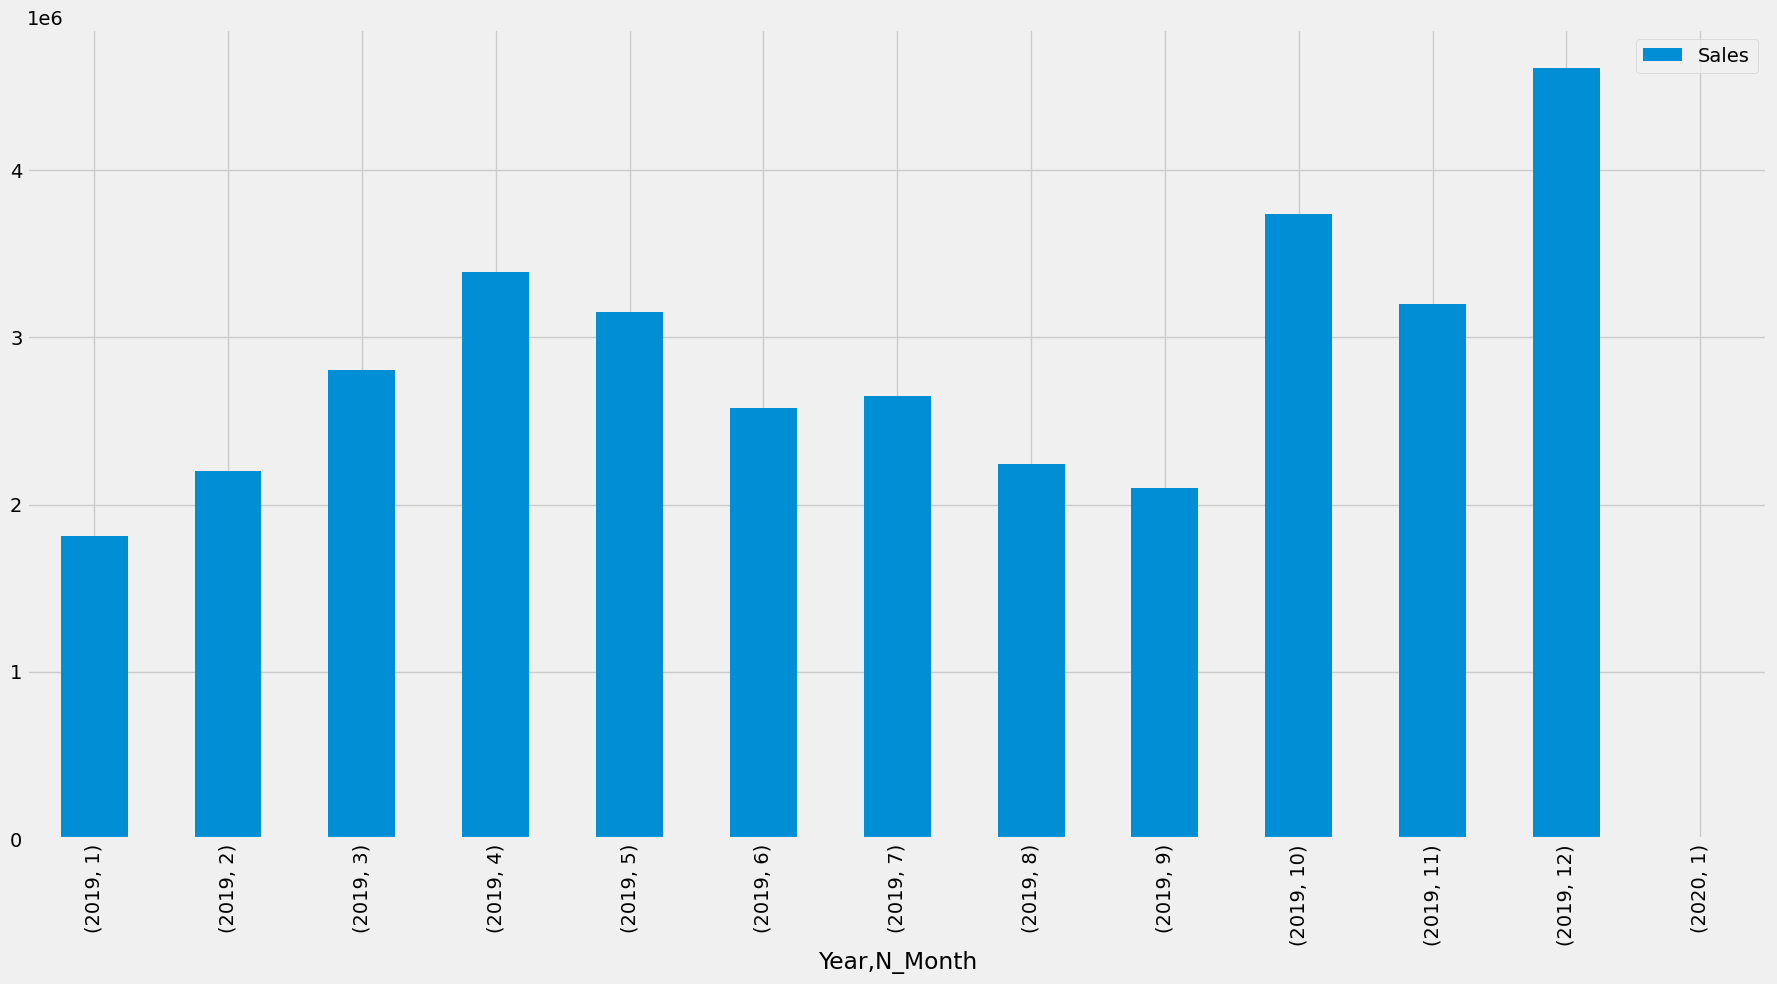

In [22]:
s_month.plot(kind = 'bar' , figsize =(20 , 10)) #PLot the sales of each month by year
plt.legend()

From the plot we can see that the best sales are in december 2019 and almost no sales in juanary 2020

let's work on 2019 data only

In [23]:
# dividing the dataset into 2019 and 2020 datasets
df_19 = df.loc[df.Year == 2019,:]
df_19.to_csv('2019_clr_data.csv' , index = False)

df_20 = df.loc[df.Year == 2020,:]
df_20.to_csv('2020_clr_data.csv' , index = False)

df_19.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,N_Month,Sales,Year
32308,297481,AA Batteries (4-pack),1,3.84,2019-12-31 23:42:00,"82 Hill St, Dallas, TX 75001",12,3.84,2019
33264,298406,AAA Batteries (4-pack),2,2.99,2019-12-31 23:42:00,"30 Elm St, San Francisco, CA 94016",12,5.98,2019
52781,317048,AAA Batteries (4-pack),2,2.99,2019-12-31 23:45:00,"743 Adams St, San Francisco, CA 94016",12,5.98,2019
45172,309773,AAA Batteries (4-pack),1,2.99,2019-12-31 23:52:00,"60 Hickory St, Los Angeles, CA 90001",12,2.99,2019
32511,297674,AAA Batteries (4-pack),1,2.99,2019-12-31 23:53:00,"425 Lake St, Portland, OR 97035",12,2.99,2019


## Answering Questions

### Question 1: What was the best month for sales? How much was earned that month?

##### Ploting the sales for each month in 2019

In [24]:
lst = df_19['Order Date'].dt.month_name().unique() #list of months name
s_19 = df_19.groupby('N_Month').Sales.sum() # the sum of the sales in each month for year 2019
s_19.index = lst # changing from months number to months name
s_19

January      1813586.44
February     2202022.42
March        2807100.38
April        3390670.24
May          3152606.75
June         2577802.26
July         2647775.76
August       2244467.88
September    2097560.13
October      3736726.88
November     3199603.20
December     4613443.34
Name: Sales, dtype: float64

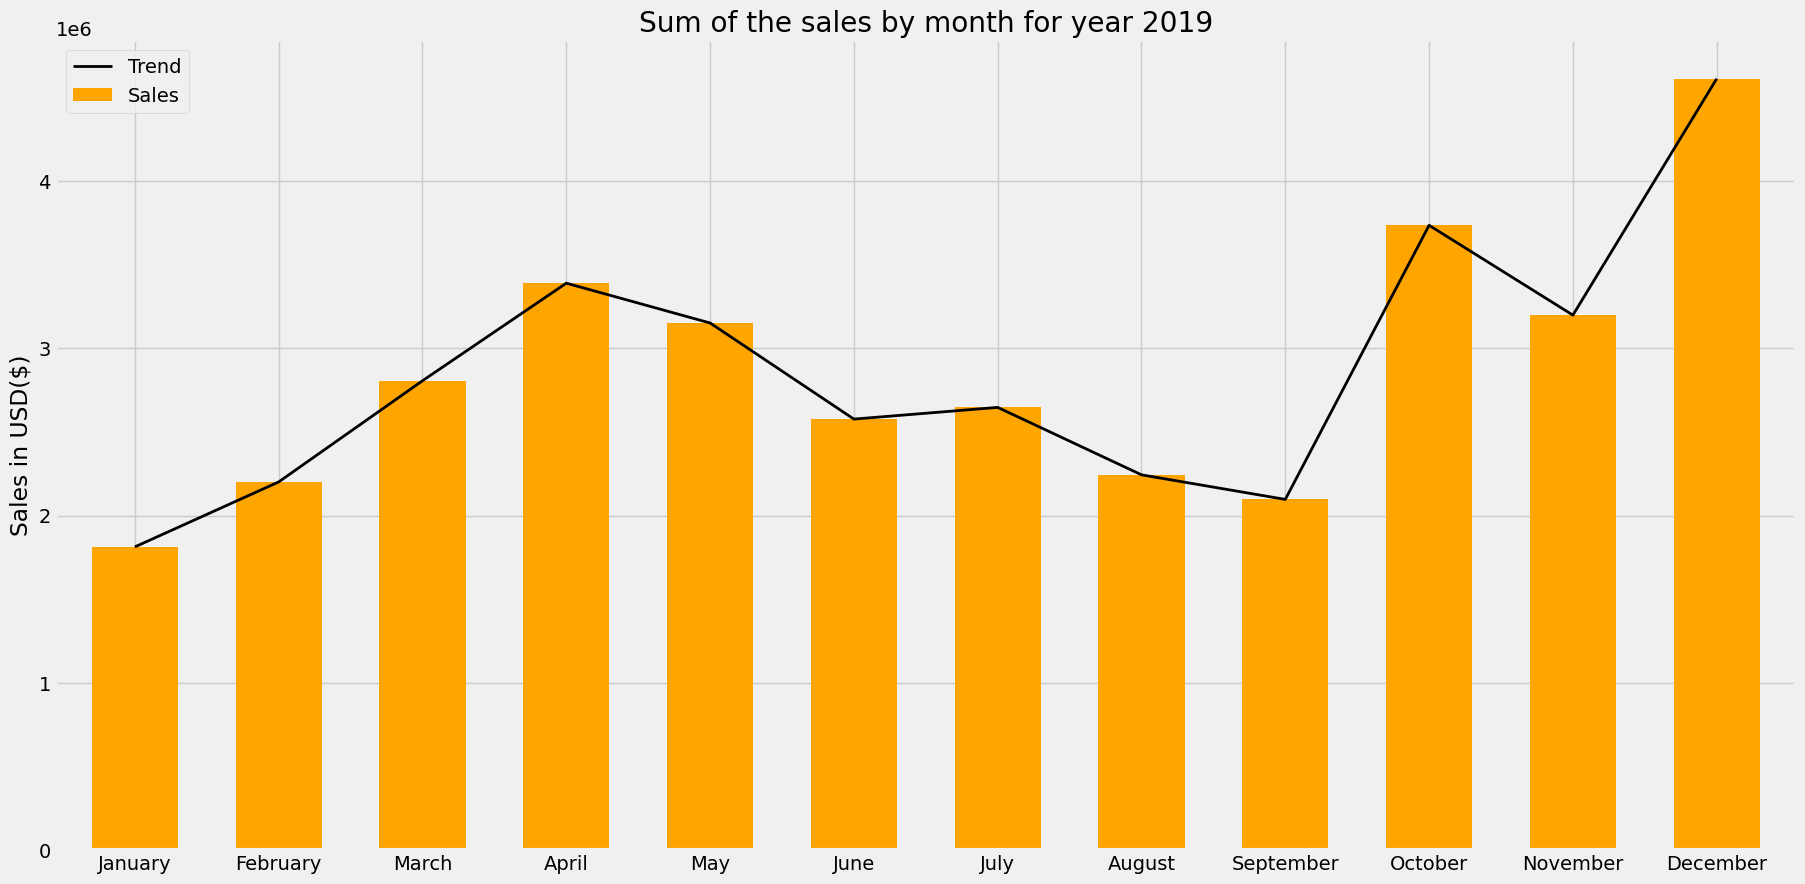

In [25]:
s_19.plot(kind = 'bar',  color = 'orange' , figsize =(20 , 10), width=0.6 )
s_19.plot(kind = 'line' ,c = 'black' , linewidth=2 , label = 'Trend')
plt.title('Sum of the sales by month for year 2019')
plt.ylabel('Sales in USD($)')
plt.legend()
plt.show()

###### We can see here that there's a raise in sales from January till april then a little decrease in May till September , then a huge raise in October till December which is the end of the year recording 4.6m dollars. That raise might be due to the national and international holidays in the US Like Christimas.



# Question 2 : Which city had the highest number of sales?

##### Adding a city column

In [26]:
# Adding the city and state name to avoid dublicates for states with cities with the same name. 
df_19['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1] +' (' + x.split(',')[-1][1:3]+ ')')
df_19.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,N_Month,Sales,Year,City
73891,147268,Wired Headphones,1,11.99,2019-01-01 03:07:00,"9 Lake St, New York City, NY 10001",1,11.99,2019,New York City (NY)
74701,148041,USB-C Charging Cable,1,11.95,2019-01-01 03:40:00,"760 Church St, San Francisco, CA 94016",1,11.95,2019,San Francisco (CA)
76054,149343,Apple Airpods Headphones,1,150.00,2019-01-01 04:56:00,"735 5th St, New York City, NY 10001",1,150.00,2019,New York City (NY)
76708,149964,AAA Batteries (4-pack),1,2.99,2019-01-01 05:53:00,"75 Jackson St, Dallas, TX 75001",1,2.99,2019,Dallas (TX)
76061,149350,USB-C Charging Cable,2,11.95,2019-01-01 06:03:00,"943 2nd St, Atlanta, GA 30301",1,23.90,2019,Atlanta (GA)


In [27]:
s_city = df_19.groupby('City').Sales.sum() #the sum of the sales in each city for year 2019
s_city

City
 Atlanta (GA)          2795498.58
 Austin (TX)           1819081.77
 Boston (MA)           3660315.12
 Dallas (TX)           2766260.45
 Los Angeles (CA)      5451570.81
 New York City (NY)    4662976.81
 Portland (ME)          449758.27
 Portland (OR)         1870579.35
 San Francisco (CA)    8259719.03
 Seattle (WA)          2747605.49
Name: Sales, dtype: float64

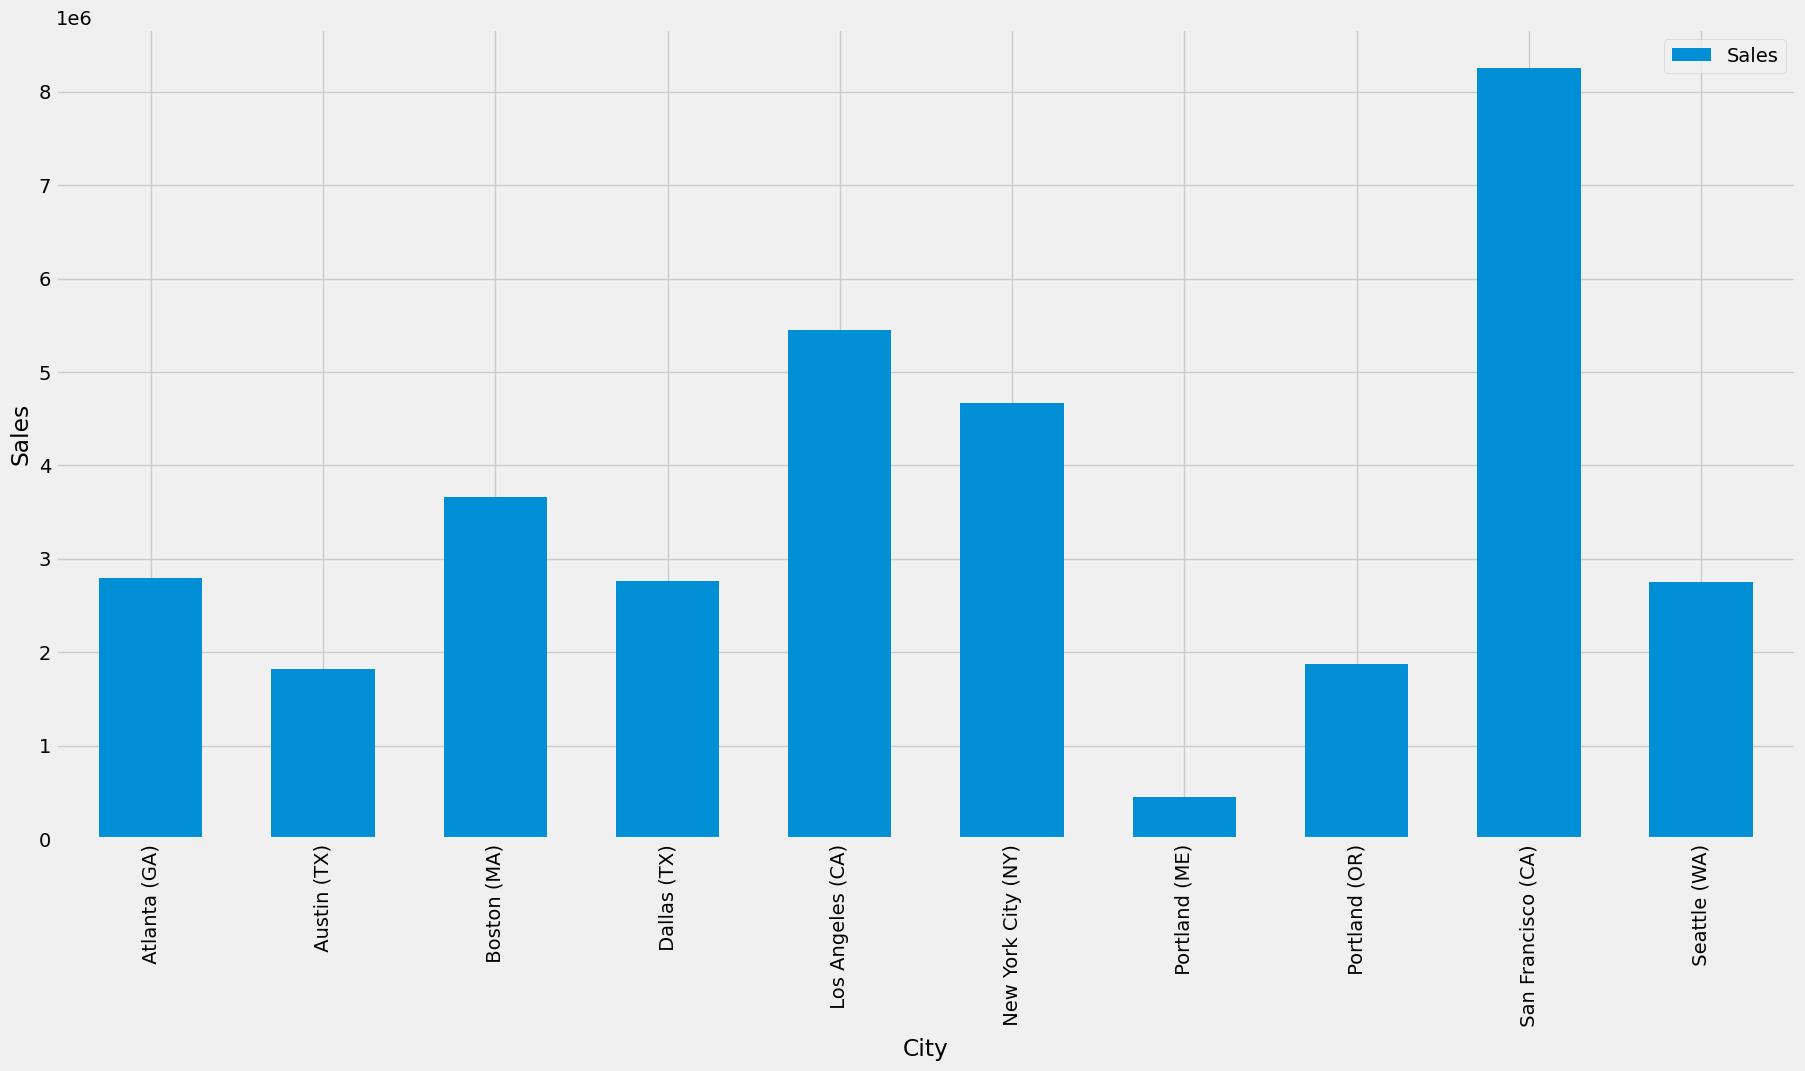

In [28]:
s_city.plot(kind = 'bar' , figsize=(20 , 10) , width = 0.6)
plt.ylabel('Sales')
plt.legend()
plt.show()

### we can see here that San Francisco in CA state had the highest sales. This might be due to San Francisco is the commercial and financial center of California. While Portland in ME has the lowest sales as it's only a tourist destination
#### Suggestions: the company should set and manage more advertisments in the low sales states

## Question 3: What time should we display advertisements to maximize the likelihood of purchasses and Sales?

In [29]:
df_19['Hour'] = df_19['Order Date'].dt.hour # adding hour column
df_19['Minute'] = df_19['Order Date'].dt.minute # adding minute column
df_19.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,N_Month,Sales,Year,City,Hour,Minute
73891,147268,Wired Headphones,1,11.99,2019-01-01 03:07:00,"9 Lake St, New York City, NY 10001",1,11.99,2019,New York City (NY),3,7
74701,148041,USB-C Charging Cable,1,11.95,2019-01-01 03:40:00,"760 Church St, San Francisco, CA 94016",1,11.95,2019,San Francisco (CA),3,40
76054,149343,Apple Airpods Headphones,1,150.00,2019-01-01 04:56:00,"735 5th St, New York City, NY 10001",1,150.00,2019,New York City (NY),4,56
76708,149964,AAA Batteries (4-pack),1,2.99,2019-01-01 05:53:00,"75 Jackson St, Dallas, TX 75001",1,2.99,2019,Dallas (TX),5,53
76061,149350,USB-C Charging Cable,2,11.95,2019-01-01 06:03:00,"943 2nd St, Atlanta, GA 30301",1,23.90,2019,Atlanta (GA),6,3


<Axes: xlabel='N_Month,Hour'>

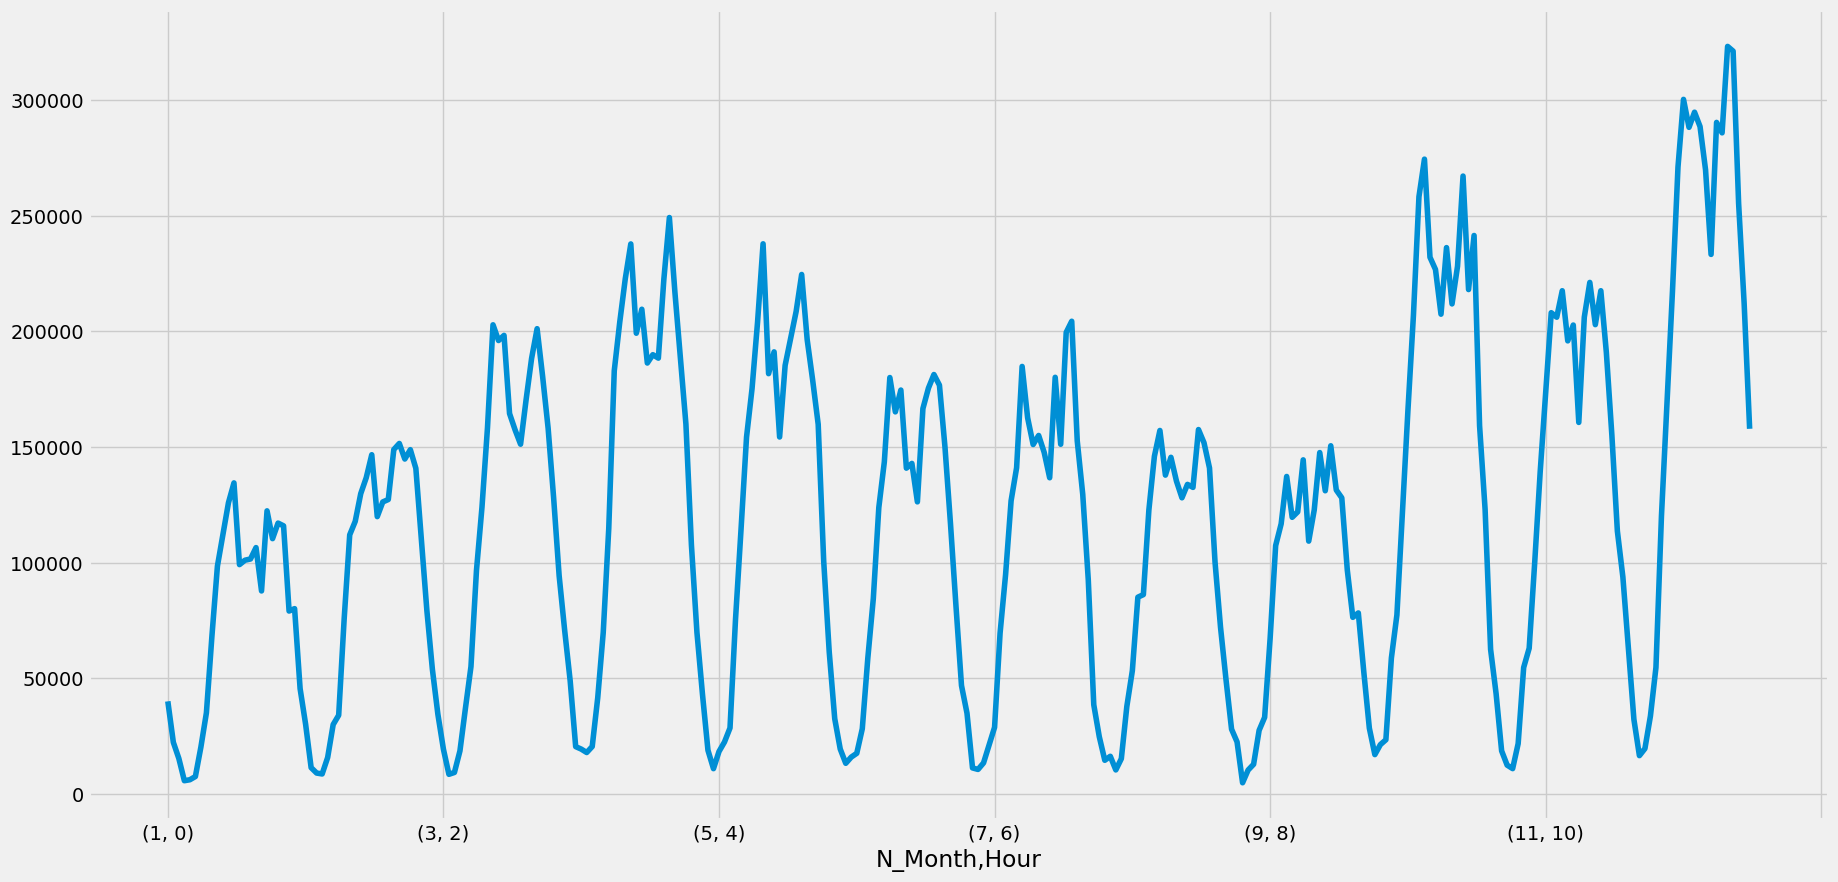

In [30]:
m_hours = [hour for hour ,df in df_19.groupby(['N_Month','Hour'])]
df_19.groupby(['N_Month','Hour']).Sales.sum().plot(kind = 'line' , figsize=(20,10))

Here we conclude that the ratio in increase or decrease in the sales for an hour is the same for all months

#### Let's answer the question without taking the month into account

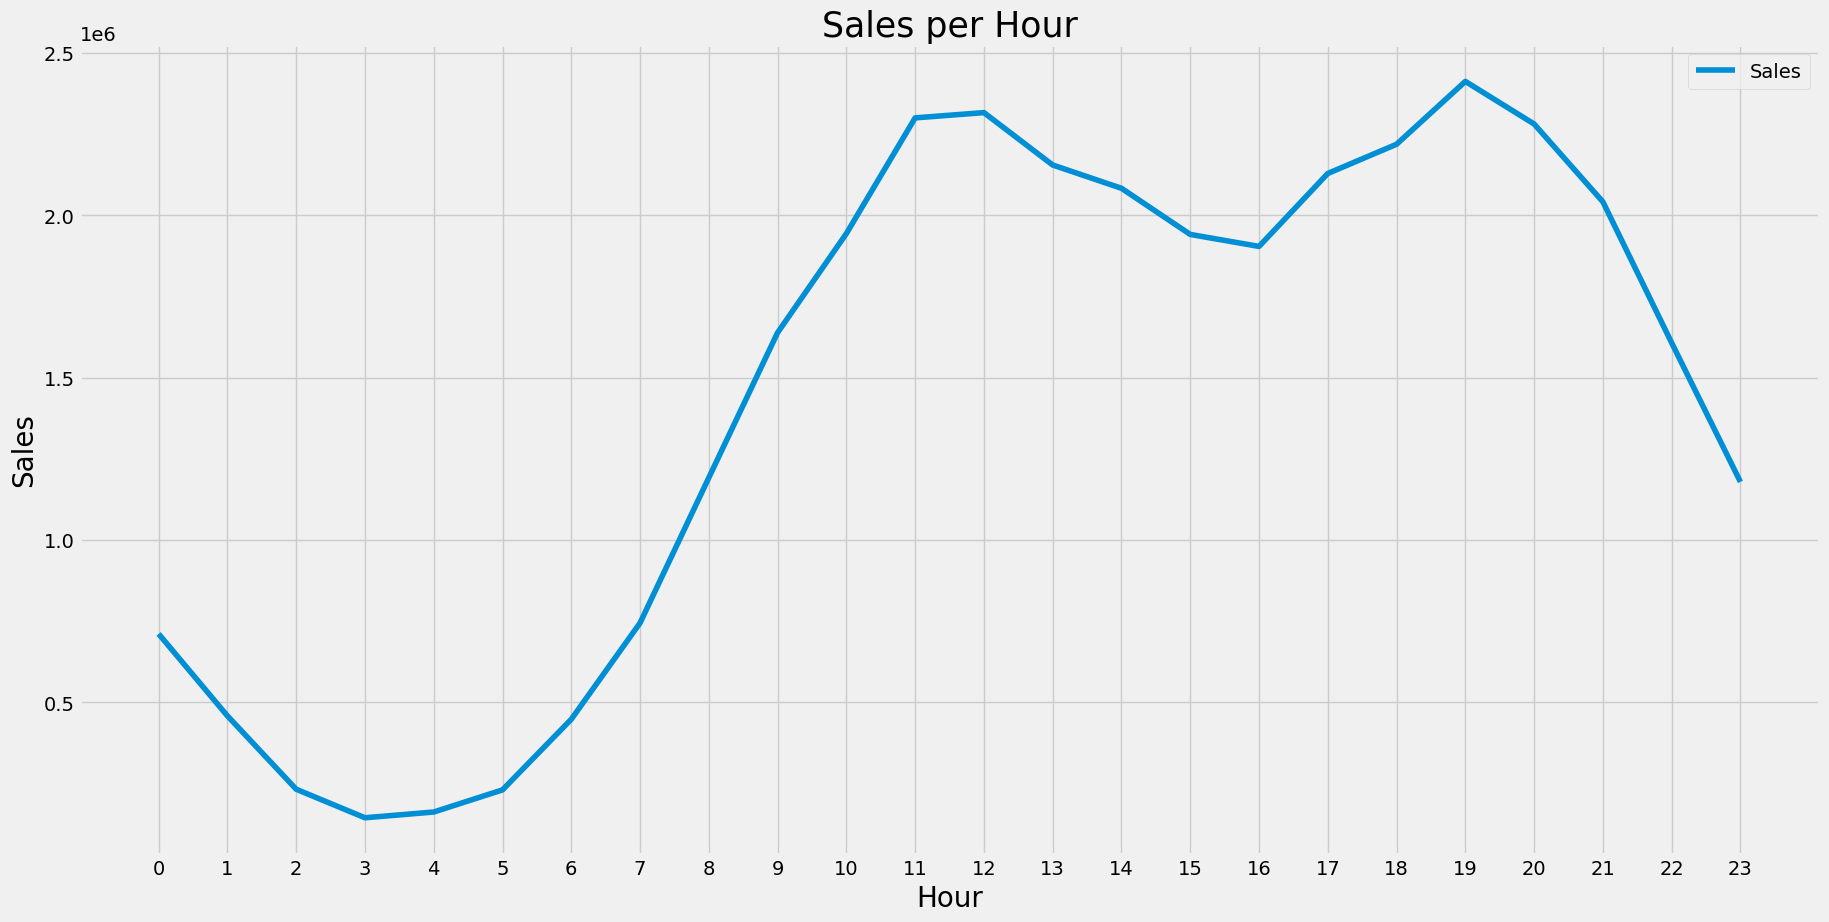

In [31]:
hours = [hour[0] for hour in df_19.groupby('Hour')]
df_19.groupby('Hour').Sales.sum().plot(kind ='line' , figsize = (20,10))
plt.xticks(hours)
plt.title('Sales per Hour' , size = 25)
plt.xlabel('Hour',size = 20)
plt.ylabel('Sales' , size = 20)
plt.legend()
plt.show()

The company should set the advertisments from 10-(AM) to 19-(7 PM) as this is the time highest number of peaple are active and can see the advertisments

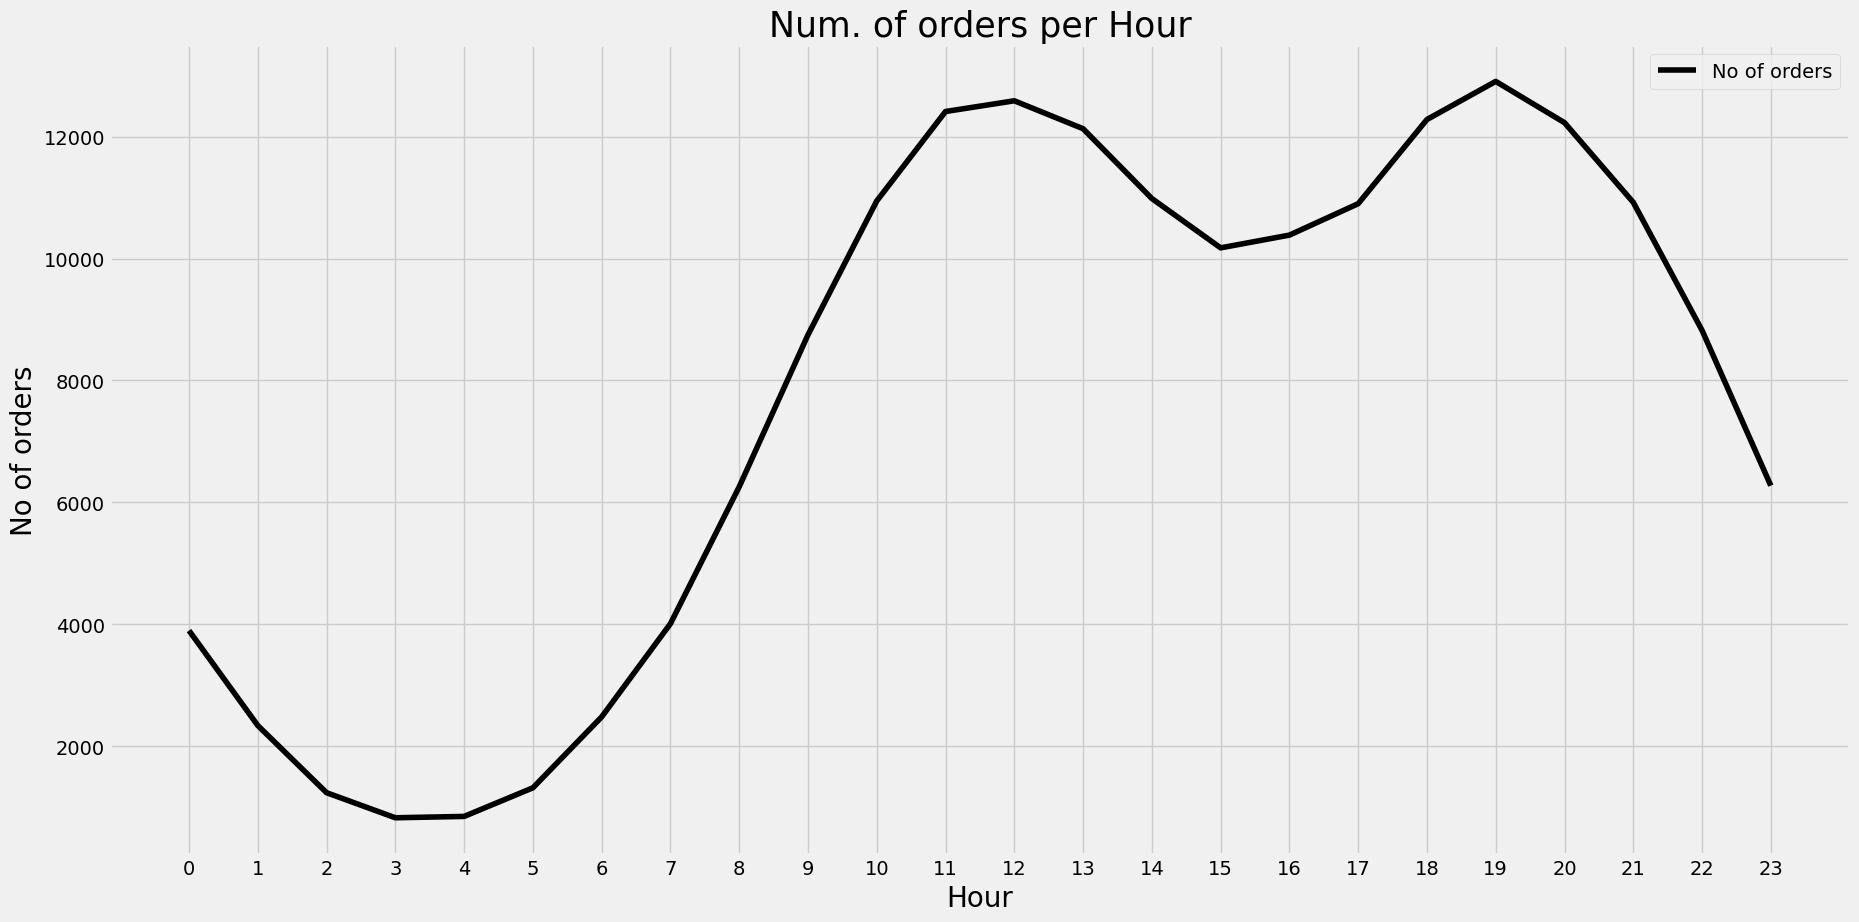

In [32]:
df_19.groupby('Hour')['Order ID'].count().plot(kind ='line' , figsize = (20,10) , c = 'black' , label = 'No of orders')
plt.xticks(hours)
plt.title('Num. of orders per Hour' ,size = 25)
plt.xlabel('Hour',size = 20)
plt.ylabel('No of orders' , size = 20)
plt.legend()
plt.show()

Here we see that the highest number of orders is from 11am to 19(7pm) 

# Question 4: What products are most often sold together?

###### If the products have the same order id and the same purchase addres that means they are sold together

In [33]:
# check dublicates for order id with the same purchase address and ading them in a seperated column
products = df_19[df_19.duplicated(subset=['Order ID' ,'Purchase Address'] ,keep = False)]
products['gr_products'] = products.groupby('Order ID').Product.transform(lambda x : ','.join(x))
products.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,N_Month,Sales,Year,City,Hour,Minute,gr_products
71310,144804,iPhone,1,700.00,2019-01-01 07:29:00,"628 Lake St, New York City, NY 10001",1,700.00,2019,New York City (NY),7,29,"iPhone,Wired Headphones"
71311,144804,Wired Headphones,1,11.99,2019-01-01 07:29:00,"628 Lake St, New York City, NY 10001",1,11.99,2019,New York City (NY),7,29,"iPhone,Wired Headphones"
74737,148074,USB-C Charging Cable,1,11.95,2019-01-01 11:25:00,"6 Johnson St, Atlanta, GA 30301",1,11.95,2019,Atlanta (GA),11,25,"USB-C Charging Cable,Google Phone"
74736,148074,Google Phone,1,600.00,2019-01-01 11:25:00,"6 Johnson St, Atlanta, GA 30301",1,600.00,2019,Atlanta (GA),11,25,"USB-C Charging Cable,Google Phone"
75123,148450,iPhone,1,700.00,2019-01-01 12:02:00,"761 Lakeview St, Dallas, TX 75001",1,700.00,2019,Dallas (TX),12,2,"iPhone,Lightning Charging Cable"


In [34]:
products = products[['Order ID' , 'gr_products']].drop_duplicates()
products.head()

,Order ID,gr_products
71310,144804,"iPhone,Wired Headphones"
74737,148074,"USB-C Charging Cable,Google Phone"
75123,148450,"iPhone,Lightning Charging Cable"
71177,144679,"USB-C Charging Cable,Google Phone"
74085,147451,"Wired Headphones,Google Phone"


In [35]:
products.gr_products.value_counts()

gr_products
Lightning Charging Cable,iPhone                               458
USB-C Charging Cable,Google Phone                             453
iPhone,Lightning Charging Cable                               432
Google Phone,USB-C Charging Cable                             415
Wired Headphones,iPhone                                       191
                                                             ... 
iPhone,Lightning Charging Cable,34in Ultrawide Monitor          1
iPhone,Bose SoundSport Headphones,Apple Airpods Headphones      1
LG Washing Machine,iPhone                                       1
Vareebadd Phone,27in 4K Gaming Monitor                          1
Google Phone,34in Ultrawide Monitor                             1
Name: count, Length: 418, dtype: int64

##### we can see here that the first and the third row are the same pairs of products but in different order so each row was counted as a unique one ,the same also applys to the 2nd and the 4th, let's fix this by sorting the items in each cell of the column

In [36]:
products['gr_products'] = products['gr_products'].apply(lambda x : ','.join(sorted(x.lower().split(','))))
products['gr_products'].value_counts()

gr_products
iphone,lightning charging cable                                                        890
google phone,usb-c charging cable                                                      868
iphone,wired headphones                                                                374
usb-c charging cable,vareebadd phone                                                   318
google phone,wired headphones                                                          311
                                                                                      ... 
google phone,usb-c charging cable,usb-c charging cable                                   1
apple airpods headphones,google phone,usb-c charging cable                               1
lg dryer,wired headphones                                                                1
34in ultrawide monitor,iphone,lightning charging cable                                   1
34in ultrawide monitor,bose soundsport headphones,google phone,usb-c charging 

###### Perfect all the pairs were counted correctly, now to answer our question ''What products are most often sold together?'' we need to count the compinations of each unique pair

In [37]:
max_num_items = []
for i in products['gr_products']:
    max_num_items.append(len(i.split(',')))
max_num = max(max_num_items)
max_num

5

In [38]:
from itertools import combinations
from collections import Counter

count_p = {}
for num in range(2,max_num+1):
    num_count_p = str(num)+('_pairs')
    count = Counter()

    for order in products['gr_products']:
        row_list = order.split(',')
        count.update(Counter(combinations(row_list,num)))
    
    count_p[num_count_p] = count


for key , value in count_p.items():
    print('For ' + key +':' + '\n')
    print(*value.most_common(6))
    print('--------------------------------------------------------------------------------------' + '\n')
    print('--------------------------------------------------------------------------------------'+ '\n')


For 2_pairs:

(('iphone', 'lightning charging cable'), 1014) (('google phone', 'usb-c charging cable'), 999) (('iphone', 'wired headphones'), 462) (('google phone', 'wired headphones'), 423) (('apple airpods headphones', 'iphone'), 372) (('usb-c charging cable', 'vareebadd phone'), 368)
--------------------------------------------------------------------------------------

--------------------------------------------------------------------------------------

For 3_pairs:

(('google phone', 'usb-c charging cable', 'wired headphones'), 89) (('iphone', 'lightning charging cable', 'wired headphones'), 63) (('apple airpods headphones', 'iphone', 'lightning charging cable'), 47) (('bose soundsport headphones', 'google phone', 'usb-c charging cable'), 35) (('usb-c charging cable', 'vareebadd phone', 'wired headphones'), 33) (('apple airpods headphones', 'iphone', 'wired headphones'), 27)
--------------------------------------------------------------------------------------

-----------------

###### From above we see for 2 pairs of products whenever a customer buys a cell phone, chances for buying a charging cable is highe and it's even hieghert in the 3 pairs of products as well as a wired headphones in the order.

###### so when ever a customer buys a cell phone the company should recommned and set an advertisment for charging cable (USB-C for google phones & LIghtining charging cable for iphone users) and wired headphones(or airpods) to that customer to increase the sales 

# Question 5: Which product was sold the most?

In [39]:
num_po = df_19.groupby('Product')['Quantity Ordered'].sum()
num_po

Product
20in Monitor                   4126
27in 4K Gaming Monitor         6243
27in FHD Monitor               7547
34in Ultrawide Monitor         6199
AA Batteries (4-pack)         27635
AAA Batteries (4-pack)        31012
Apple Airpods Headphones      15657
Bose SoundSport Headphones    13454
Flatscreen TV                  4818
Google Phone                   5531
LG Dryer                        646
LG Washing Machine              666
Lightning Charging Cable      23211
Macbook Pro Laptop             4727
ThinkPad Laptop                4128
USB-C Charging Cable          23971
Vareebadd Phone                2067
Wired Headphones              20553
iPhone                         6847
Name: Quantity Ordered, dtype: int32

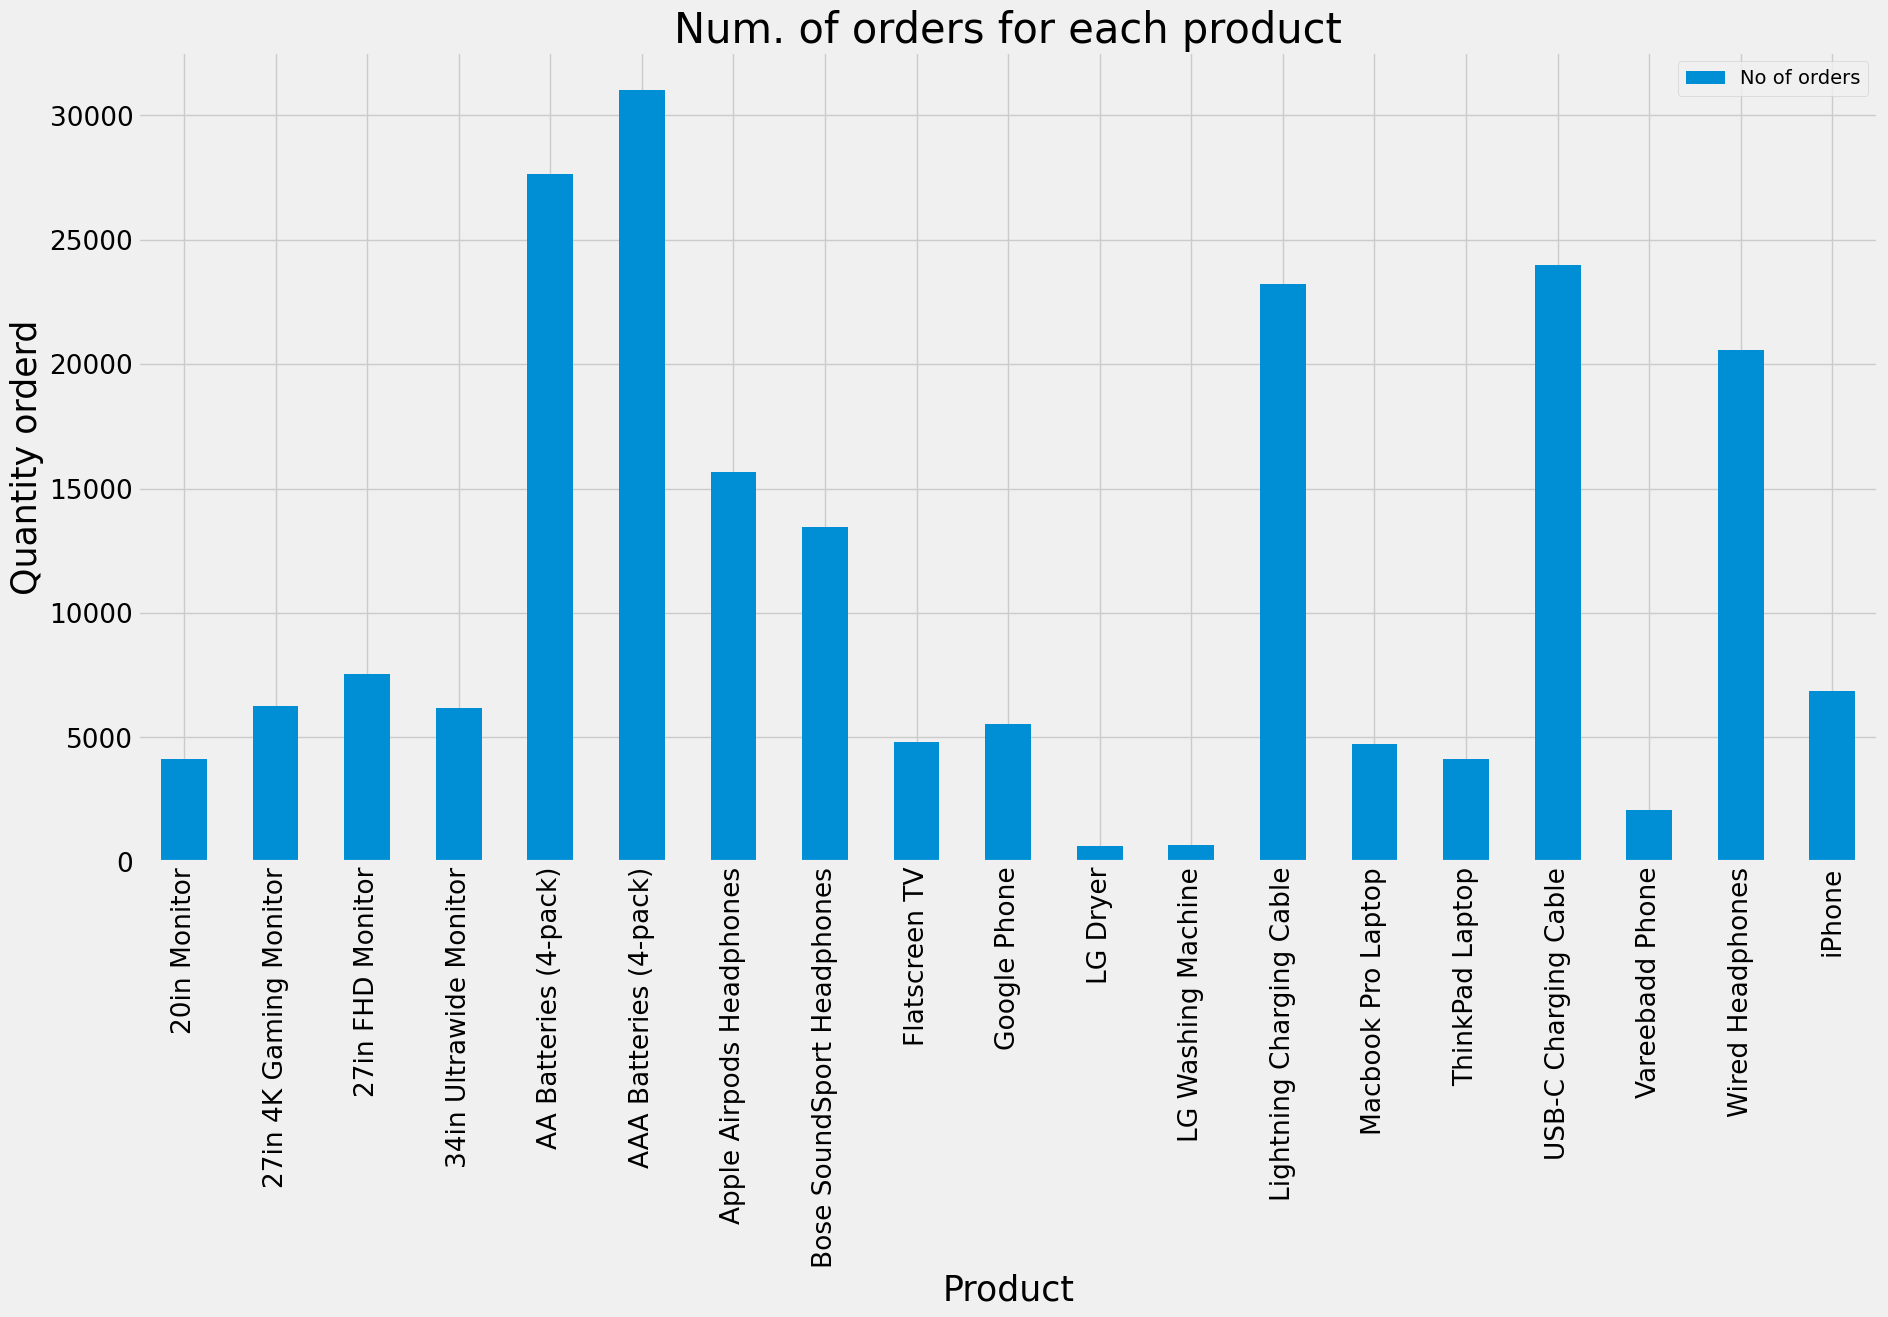

In [40]:
num_po.plot(kind='bar' , figsize = (20 , 10) , label = 'No of orders')
plt.xticks(size = 19)
plt.yticks(size = 19)
plt.title('Num. of orders for each product' , size = 30)
plt.xlabel('Product' , size =25)
plt.ylabel('Quantity orderd', size = 25)
plt.legend()
plt.show();

###### We see that AAA Batteries (4-pack) was sold the most

In [41]:
df_20

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,N_Month,Sales,Year
46840,311386,Apple Airpods Headphones,1,150.00,2020-01-01 00:10:00,"730 Pine St, San Francisco, CA 94016",1,150.00,2020
46839,311386,iPhone,1,700.00,2020-01-01 00:10:00,"730 Pine St, San Francisco, CA 94016",1,700.00,2020
35749,300759,20in Monitor,1,109.99,2020-01-01 00:14:00,"193 5th St, Austin, TX 73301",1,109.99,2020
37442,302393,Lightning Charging Cable,1,14.95,2020-01-01 00:14:00,"108 Jefferson St, Boston, MA 02215",1,14.95,2020
32659,297817,iPhone,1,700.00,2020-01-01 00:22:00,"519 13th St, New York City, NY 10001",1,700.00,2020
32660,297817,Lightning Charging Cable,2,14.95,2020-01-01 00:22:00,"519 13th St, New York City, NY 10001",1,29.90,2020
43656,308322,Bose SoundSport Headphones,1,99.99,2020-01-01 00:24:00,"362 Willow St, San Francisco, CA 94016",1,99.99,2020
31957,297150,Lightning Charging Cable,1,14.95,2020-01-01 00:38:00,"427 Wilson St, Dallas, TX 75001",1,14.95,2020
55198,319366,20in Monitor,2,109.99,2020-01-01 00:45:00,"746 South St, San Francisco, CA 94016",1,219.98,2020
50774,315138,AAA Batteries (4-pack),3,2.99,2020-01-01 00:51:00,"257 Adams St, New York City, NY 10001",1,8.97,2020


##### 2020 Sales data is too small for analysis or for even being compared to the first month in 2019


# ------------------------------------------


# conclusion:
# Wrangler:-
Downloaded the data csv file from kaggel website , We found the data was seperated in diffrent excel sheets so we concatenate them together. we found some rows with only nan values so we should remove them before the analysis. We also cleaned and dealed with dublicated rows in the most aproperiate way.

We also have done some editing on the variables for clearification as change the data type of 'Quantity Ordered' from string to integers , 'Price Each' from string to float and 'Order Date' from string to Date and time.

We started our analysis by asking questions and visualizing the data to answer them.

# Limitations:

1 - The dataset is only for year 2019

2 - statistics are only describitive 

3 - we dont have the required details to make forecasting about the sales of upcoming years and how to increase them in the future 

In [42]:
df_19.to_csv('2019_clr_data.csv(2) ' , index = False)